# BB-Code QEC Tests: RL--GNN vs MWPM

This notebook evaluates trained RL--GNN decoders on a bivariate bicycle CSS code. Stim is used to generate Pauli error samples and syndrome data. PyMatching is used as a graphlike MWPM baseline; because the BB parity checks have column weight three, the PyMatching comparison is a projected MWPM baseline rather than an exact decoder for the full BB check matrix.


In [164]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import itertools
import json
import sys
import time
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from scipy.sparse import csr_matrix, hstack

import stim
import pymatching

PROJECT_CODE = Path.cwd().resolve()
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

import utils
utils = importlib.reload(utils)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 17,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Stim: {stim.__version__}")
print(f"PyMatching: {getattr(pymatching, '__version__', 'unknown')}")
print(f"utils.py: {utils.__file__}")


Device: cpu
Stim: 1.16.dev1774991977
PyMatching: 2.3.1
utils.py: C:\Users\Jogga\Documents\V26\FYS5429\Project\Code\utils.py


## 1. Experiment Settings

The notebook reads the strongest models from the training notebook, retrains their X- and Z-component decoders, then evaluates them on fresh Stim-generated Pauli noise.


In [165]:
TOP_K_MODELS = 3
EVAL_EPISODES = 120
STRESS_EPISODES = 80
NOISE_RATES = np.array([0.005, 0.010, 0.020, 0.030, 0.040, 0.060])
STRESS_ERROR_WEIGHT = list(range(0, 9))

RESULTS_DIR = Path("test_results") / "bb_rl_gnn_qec"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEARCH_RESULTS_PATHS = [
    Path("training_results/medium-bb-lite_expanded/search_results.csv"),
    Path("training_results/medium-bb-lite_quick/search_results.csv"),
]
BEST_CONFIG_PATHS = [
    Path("training_results/medium-bb-lite_expanded/best_config.json"),
    Path("rl_tests/results_notebooks/medium-bb-lite_quick/best_config.json"),
]


## 2. Models Under Test

The QEC evaluation does not perform a new hyperparameter search. It takes the top configurations from `training.ipynb` and asks how well they decode fresh BB-code noise.


In [166]:
DEFAULT_CONFIG = {
    "name": "fallback_rl_gnn",
    "hidden_dim": 48,
    "layers": 3,
    "lr": 7e-4,
    "imitation_batches": 45,
    "imitation_batch_size": 18,
    "rl_episodes": 90,
    "gamma": 0.97,
    "entropy_coef": 0.001,
    "value_coef": 0.5,
    "max_steps": 12,
    "p_train": 0.04,
    "min_train_weight": 1,
    "max_train_weight": 2,
    "teacher": "exact",
    "seed": 1018,
}

if any(path.exists() for path in SEARCH_RESULTS_PATHS):
    search_path = next(path for path in SEARCH_RESULTS_PATHS if path.exists())
    config_table = pd.read_csv(search_path).sort_values("score", ascending=False).head(TOP_K_MODELS)
    configs = config_table.to_dict("records")
    print(f"Loaded top {len(configs)} configs from {search_path}")
elif any(path.exists() for path in BEST_CONFIG_PATHS):
    best_path = next(path for path in BEST_CONFIG_PATHS if path.exists())
    configs = [json.loads(best_path.read_text(encoding="utf-8"))]
    print(f"Loaded one config from {best_path}")
else:
    configs = [DEFAULT_CONFIG]
    print("Using fallback config")

for rank, config in enumerate(configs, start=1):
    config["rank"] = rank
    config["label"] = f"RL-GNN {rank}"
    for key in ["hidden_dim", "layers", "imitation_batches", "imitation_batch_size", "rl_episodes", "max_steps", "min_train_weight", "max_train_weight", "seed"]:
        config[key] = int(config[key])
    for key in ["lr", "gamma", "entropy_coef", "value_coef", "p_train"]:
        config[key] = float(config[key])

columns = ["rank", "label", "name", "hidden_dim", "layers", "lr", "entropy_coef", "max_steps"]
if "score" in configs[0]:
    columns.append("score")
display(pd.DataFrame(configs)[columns])


Loaded top 3 configs from training_results\medium-bb-lite_expanded\search_results.csv


,rank,label,name,hidden_dim,layers,lr,entropy_coef,max_steps,score
0,1,RL-GNN 1,medium-bb-lite_expanded_018,48,3,0.0007,0.001,12,0.961333
1,2,RL-GNN 2,medium-bb-lite_expanded_014,48,2,0.0007,0.001,12,0.947583
2,3,RL-GNN 3,medium-bb-lite_expanded_045,96,4,0.0003,0.005,12,0.946250


## 3. BB Code and Stim Syndromes

Stim represents Pauli errors and checks as Pauli strings. A syndrome bit is one when the sampled error anticommutes with the corresponding check. This gives the same CSS syndromes as multiplying by the parity-check matrices, but keeps the data-generation layer explicitly Pauli based.


In [167]:
def bb_shift_matrix(l, m, x_pow, y_pow):
    rows, cols = [], []
    for x in range(l):
        for y in range(m):
            src = x * m + y
            dst = ((x + x_pow) % l) * m + ((y + y_pow) % m)
            rows.append(dst)
            cols.append(src)
    return csr_matrix((np.ones(l * m, dtype=np.uint8), (rows, cols)), shape=(l * m, l * m), dtype=np.uint8)


def bb_polynomial_matrix(l, m, terms):
    matrix = csr_matrix((l * m, l * m), dtype=np.uint8)
    for x_pow, y_pow in terms:
        matrix += bb_shift_matrix(l, m, x_pow, y_pow)
    matrix.data %= 2
    matrix.eliminate_zeros()
    return matrix


def bivariate_bicycle_code(l, m):
    a = bb_polynomial_matrix(l, m, [(3, 0), (0, 1), (0, 2)])
    b = bb_polynomial_matrix(l, m, [(0, 3), (1, 0), (2, 0)])
    hx = hstack([a, b], format="csr", dtype=np.uint8)
    hz = hstack([b.T, a.T], format="csr", dtype=np.uint8)
    return hx, hz


L, M = 6, 6
hx, hz = bivariate_bicycle_code(L, M)
n_qubits = hx.shape[1]
css_valid = int((hx @ hz.T).nnz) == 0

display(pd.DataFrame([{
    "code": f"BB({L},{M})",
    "qubits": n_qubits,
    "X checks": hx.shape[0],
    "Z checks": hz.shape[0],
    "Hx col wt": sorted(set(hx.getnnz(axis=0).tolist())),
    "Hz col wt": sorted(set(hz.getnnz(axis=0).tolist())),
    "CSS valid": css_valid,
}]))


,code,qubits,X checks,Z checks,Hx col wt,Hz col wt,CSS valid
0,"BB(6,6)",72,36,36,[3],[3],False


In [168]:
class StimCSSSampler:
    """Stim-backed Pauli-error and syndrome sampler for the BB CSS code."""

    def __init__(self, hx, hz, seed=0):
        self.hx = utils.to_csr_binary(hx)
        self.hz = utils.to_csr_binary(hz)
        self.n = self.hx.shape[1]
        self.rng = np.random.default_rng(seed)
        self.x_checks = self._checks_to_pauli_strings(self.hx, "X")
        self.z_checks = self._checks_to_pauli_strings(self.hz, "Z")

    def _checks_to_pauli_strings(self, check_matrix, basis):
        checks = []
        for row in range(check_matrix.shape[0]):
            ps = stim.PauliString(self.n)
            for q in check_matrix[row].nonzero()[1]:
                ps[int(q)] = basis
            checks.append(ps)
        return checks

    def _error_to_pauli_string(self, x_error, z_error):
        ps = stim.PauliString(self.n)
        for q, (x_bit, z_bit) in enumerate(zip(x_error, z_error)):
            if x_bit and z_bit:
                ps[q] = "Y"
            elif x_bit:
                ps[q] = "X"
            elif z_bit:
                ps[q] = "Z"
        return ps

    def syndrome_from_components(self, x_error, z_error):
        error_ps = self._error_to_pauli_string(x_error, z_error)
        hx_syndrome = np.array([not error_ps.commutes(check) for check in self.x_checks], dtype=np.uint8)
        hz_syndrome = np.array([not error_ps.commutes(check) for check in self.z_checks], dtype=np.uint8)
        return hx_syndrome, hz_syndrome

    def sample_pauli_error(self, p_error):
        has_error = self.rng.random(self.n) < p_error
        pauli = self.rng.integers(1, 4, size=self.n)
        x_error = (((pauli == 1) | (pauli == 3)) & has_error).astype(np.uint8)
        z_error = (((pauli == 2) | (pauli == 3)) & has_error).astype(np.uint8)
        hx_syndrome, hz_syndrome = self.syndrome_from_components(x_error, z_error)
        return x_error, z_error, hx_syndrome, hz_syndrome

    def sample_exact_pauli_weight(self, weight):
        x_error = np.zeros(self.n, dtype=np.uint8)
        z_error = np.zeros(self.n, dtype=np.uint8)
        if weight > 0:
            support = self.rng.choice(self.n, size=weight, replace=False)
            pauli = self.rng.integers(1, 4, size=weight)
            x_error[support] = ((pauli == 1) | (pauli == 3)).astype(np.uint8)
            z_error[support] = ((pauli == 2) | (pauli == 3)).astype(np.uint8)
        hx_syndrome, hz_syndrome = self.syndrome_from_components(x_error, z_error)
        return x_error, z_error, hx_syndrome, hz_syndrome


stim_sampler = StimCSSSampler(hx, hz, seed=123)
x0, z0, sx0, sz0 = stim_sampler.sample_pauli_error(0.05)
assert np.array_equal(sx0, utils.binary_syndrome(hx, z0))
assert np.array_equal(sz0, utils.binary_syndrome(hz, x0))
print("Stim syndrome check passed.")


Stim syndrome check passed.


## 4. Train the RL--GNN Decoders

Each configuration is trained twice: one decoder corrects X components from the Z-check syndrome, and one corrects Z components from the X-check syndrome. The sampled training errors come from the same Stim-backed Pauli model used in evaluation.


In [169]:
def syndrome_key(syndrome):
    return np.packbits(syndrome.astype(np.uint8)).tobytes()


def build_min_weight_lookup(check_matrix, max_weight=2):
    h = utils.to_csr_binary(check_matrix)
    lookup = {syndrome_key(np.zeros(h.shape[0], dtype=np.uint8)): tuple()}
    for weight in range(1, max_weight + 1):
        for support in itertools.combinations(range(h.shape[1]), weight):
            syndrome = np.asarray(h[:, support].sum(axis=1)).ravel().astype(np.uint8) % 2
            lookup.setdefault(syndrome_key(syndrome), tuple(int(q) for q in support))
    return lookup


def exact_teacher_action(env, lookup):
    if int(env.syndrome.sum()) == 0:
        return env.stop_action
    support = lookup.get(syndrome_key(env.syndrome))
    if not support:
        return utils.choose_greedy_syndrome_reducing_action(env)
    return int(support[0])


def make_stim_component_sampler(component, p_error, min_weight, max_weight, seed):
    local_sampler = StimCSSSampler(hx, hz, seed=seed)
    fallback_rng = np.random.default_rng(seed + 999)

    def sampler(n_qubits, rng):
        for _ in range(200):
            x_error, z_error, _, _ = local_sampler.sample_pauli_error(p_error)
            component_error = x_error if component == "X" else z_error
            weight = int(component_error.sum())
            if weight >= min_weight and weight <= max_weight:
                return component_error.copy()
        return utils.random_component_error(n_qubits, fallback_rng, p=p_error, min_weight=min_weight, max_weight=max_weight)

    return sampler


def make_training_env(check_matrix, config, component, seed_offset=0):
    return utils.CSSCorrectionEnv(
        check_matrix,
        max_steps=int(config["max_steps"]),
        error_sampler=make_stim_component_sampler(
            component,
            float(config["p_train"]),
            int(config["min_train_weight"]),
            int(config["max_train_weight"]),
            int(config["seed"]) + seed_offset,
        ),
        p_error=float(config["p_train"]),
        seed=int(config["seed"]) + seed_offset,
        step_penalty=-0.03,
        flip_reward_scale=0.35,
        success_reward=4.0,
        failure_reward=-2.0,
        allow_stop_when_nonzero=False,
    )


def train_exact_imitation(env, model, optimizer, lookup, batches, batch_size):
    rows = []
    model.to(DEVICE)
    for batch in range(int(batches)):
        losses, hits = [], []
        for _ in range(int(batch_size)):
            env.reset()
            for _step in range(env.max_steps):
                target = exact_teacher_action(env, lookup)
                logits, _ = model(env.node_features(DEVICE), env.action_mask(DEVICE))
                target_tensor = torch.tensor([target], dtype=torch.long, device=DEVICE)
                losses.append(torch.nn.functional.cross_entropy(logits.view(1, -1), target_tensor))
                hits.append(float(torch.argmax(logits).item() == target))
                _, _, done, _ = env.step(target)
                if done:
                    break
        loss = torch.stack(losses).mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        rows.append({"batch": batch, "teacher match": float(np.mean(hits)), "loss": float(loss.detach().cpu())})
    return pd.DataFrame(rows)


def train_component_decoder(config, check_matrix, component, seed_offset):
    env = make_training_env(check_matrix, config, component, seed_offset=seed_offset)
    model = utils.GraphActorCritic(env.graph, hidden_dim=int(config["hidden_dim"]), num_layers=int(config["layers"])).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=float(config["lr"]))
    lookup = build_min_weight_lookup(check_matrix, max_weight=2)

    start = time.perf_counter()
    imitation = train_exact_imitation(env, model, optimizer, lookup, int(config["imitation_batches"]), int(config["imitation_batch_size"]))
    rl_history = pd.DataFrame(utils.train_actor_critic(
        env,
        model,
        optimizer,
        episodes=int(config["rl_episodes"]),
        gamma=float(config["gamma"]),
        value_coef=float(config["value_coef"]),
        entropy_coef=float(config["entropy_coef"]),
        grad_clip=1.0,
        device=DEVICE,
    ))
    seconds = time.perf_counter() - start
    return model, imitation, rl_history, seconds


In [170]:
trained_models = {}
training_rows = []
all_imitation = []
all_rl = []

for config in configs:
    torch.manual_seed(int(config["seed"]))
    np.random.seed(int(config["seed"]))
    label = config["label"]
    print(f"Training {label}: hidden={config['hidden_dim']}, layers={config['layers']}, lr={config['lr']}")

    x_model, x_imitation, x_rl, x_seconds = train_component_decoder(config, hz, "X", seed_offset=10_000)
    z_model, z_imitation, z_rl, z_seconds = train_component_decoder(config, hx, "Z", seed_offset=20_000)

    trained_models[label] = {"config": config, "x_model": x_model, "z_model": z_model}
    x_imitation["model"] = label
    z_imitation["model"] = label
    x_imitation["component"] = "X"
    z_imitation["component"] = "Z"
    x_rl["model"] = label
    z_rl["model"] = label
    x_rl["component"] = "X"
    z_rl["component"] = "Z"
    all_imitation.extend([x_imitation, z_imitation])
    all_rl.extend([x_rl, z_rl])

    training_rows.append({
        "model": label,
        "hidden dim": config["hidden_dim"],
        "layers": config["layers"],
        "lr": config["lr"],
        "entropy": config["entropy_coef"],
        "X train s": x_seconds,
        "Z train s": z_seconds,
        "X teacher match": x_imitation["teacher match"].iloc[-1],
        "Z teacher match": z_imitation["teacher match"].iloc[-1],
        "X final RL success": x_rl["success"].tail(20).mean(),
        "Z final RL success": z_rl["success"].tail(20).mean(),
    })

training_summary = pd.DataFrame(training_rows)
imitation_history = pd.concat(all_imitation, ignore_index=True)
rl_history = pd.concat(all_rl, ignore_index=True)
display(training_summary.style.format({
    "X train s": "{:.1f}", "Z train s": "{:.1f}",
    "X teacher match": "{:.2f}", "Z teacher match": "{:.2f}",
    "X final RL success": "{:.2f}", "Z final RL success": "{:.2f}",
}))


Training RL-GNN 1: hidden=48, layers=3, lr=0.0007


Training RL-GNN 2: hidden=48, layers=2, lr=0.0007
Training RL-GNN 3: hidden=96, layers=4, lr=0.0003


,model,hidden dim,layers,lr,entropy,X train s,Z train s,X teacher match,Z teacher match,X final RL success,Z final RL success
0,RL-GNN 1,48,3,0.000700,0.001000,10.8,14.7,0.88,0.85,0.95,1.00
1,RL-GNN 2,48,2,0.000700,0.001000,11.2,8.7,0.85,0.91,0.90,0.65
2,RL-GNN 3,96,4,0.000300,0.005000,17.9,17.4,0.93,0.93,0.95,0.95


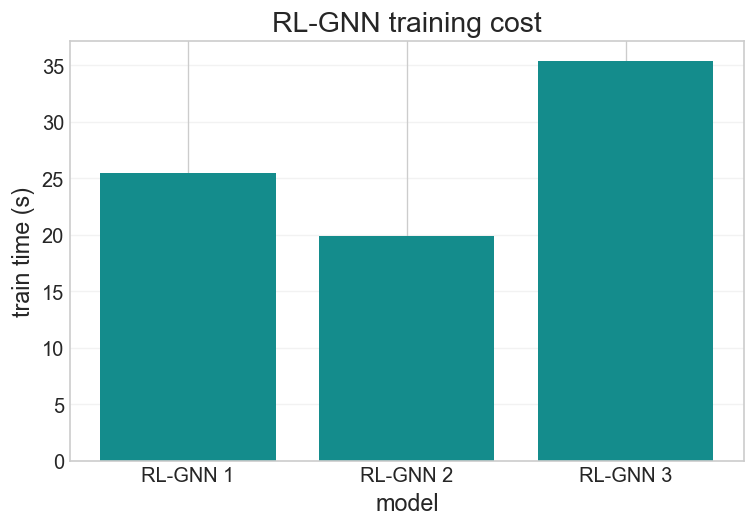

In [171]:
plot_training = training_summary.copy()
plot_training["total train s"] = plot_training["X train s"] + plot_training["Z train s"]
fig, ax = plt.subplots(figsize=(6.4, 4.5))
ax.bar(plot_training["model"], plot_training["total train s"], color="#148C8C")
ax.set_title("RL-GNN training cost")
ax.set_xlabel("model")
ax.set_ylabel("train time (s)")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 5. Baselines

PyMatching implements MWPM for graphlike detector models. Direct PyMatching does not accept this BB check matrix because each column has three ones. The notebook therefore uses a projected MWPM baseline: each three-check column is projected to a graph edge, with boundary edges added.


In [172]:
def greedy_decode(check_matrix, target_syndrome, max_steps):
    h = utils.to_csr_binary(check_matrix)
    columns = [h[:, q].toarray().ravel().astype(np.uint8) for q in range(h.shape[1])]
    current = target_syndrome.copy().astype(np.uint8)
    correction = np.zeros(h.shape[1], dtype=np.uint8)
    actions = []
    for _ in range(max_steps):
        if int(current.sum()) == 0:
            break
        old_weight = int(current.sum())
        candidate_weights = np.array([int((current ^ column).sum()) for column in columns])
        best = int(np.argmin(candidate_weights))
        if int(candidate_weights[best]) >= old_weight:
            break
        correction[best] ^= 1
        current ^= columns[best]
        actions.append(best)
    return correction, current, len(actions)


def build_projected_mwpm(check_matrix, boundary_weight=2.0):
    h = utils.to_csr_binary(check_matrix)
    matching = pymatching.Matching()
    projected_columns = 0
    for qubit in range(h.shape[1]):
        detectors = h[:, qubit].nonzero()[0].tolist()
        if len(detectors) > 2:
            projected_columns += 1
            detectors = detectors[:2]
        if len(detectors) == 1:
            matching.add_boundary_edge(detectors[0], fault_ids={qubit}, weight=1.0, merge_strategy="replace")
        elif len(detectors) >= 2:
            matching.add_edge(detectors[0], detectors[1], fault_ids={qubit}, weight=1.0, merge_strategy="replace")
    for detector in range(h.shape[0]):
        matching.add_boundary_edge(detector, weight=boundary_weight, merge_strategy="smallest-weight")
    return matching, projected_columns


def mwpm_decode(matching, check_matrix, target_syndrome):
    h = utils.to_csr_binary(check_matrix)
    decoded = matching.decode(target_syndrome.astype(np.uint8))
    correction = np.zeros(h.shape[1], dtype=np.uint8)
    correction[:min(len(decoded), h.shape[1])] = np.asarray(decoded[:h.shape[1]], dtype=np.uint8)
    final_syndrome = utils.binary_syndrome(h, correction) ^ target_syndrome
    return correction, final_syndrome, int(correction.sum())


def try_direct_pymatching(check_matrix):
    try:
        pymatching.Matching.from_check_matrix(check_matrix)
        return "accepted"
    except Exception as exc:
        return str(exc).split(".")[0]


hx_mwpm, hx_projected = build_projected_mwpm(hx)
hz_mwpm, hz_projected = build_projected_mwpm(hz)

display(pd.DataFrame([{
    "direct Hx": try_direct_pymatching(hx),
    "direct Hz": try_direct_pymatching(hz),
    "projected Hx columns": hx_projected,
    "projected Hz columns": hz_projected,
}]))


,direct Hx,direct Hz,projected Hx columns,projected Hz columns
0,`check_matrix` must contain at most two ones p...,`check_matrix` must contain at most two ones p...,72,72


## 6. Full CSS QEC Evaluation

Each episode samples a full Pauli error with Stim, splits it into X and Z components, and decodes both CSS sectors. The main metric is whether both final syndromes are cleared. Exact residual cancellation is also reported, but only as a simulation diagnostic.


In [173]:
@torch.no_grad()
def rl_gnn_decode(check_matrix, model, target_syndrome, max_steps, seed):
    h = utils.to_csr_binary(check_matrix)
    env = utils.CSSCorrectionEnv(h, max_steps=max_steps, seed=seed, allow_stop_when_nonzero=False)
    env.error = np.zeros(h.shape[1], dtype=np.uint8)
    env.correction = np.zeros(h.shape[1], dtype=np.uint8)
    env.syndrome = target_syndrome.copy().astype(np.uint8)
    done = False
    steps = 0
    while not done:
        action = model.greedy_action(env.node_features(DEVICE), env.action_mask(DEVICE))
        _, _, done, _ = env.step(action)
        steps += 1
    return env.correction.copy(), env.syndrome.copy(), steps


def decode_component(method, check_matrix, target_syndrome, true_error, model_bundle=None, component="X", seed=0):
    if method == "none":
        correction = np.zeros(check_matrix.shape[1], dtype=np.uint8)
        final = target_syndrome.copy()
        steps = 0
    elif method == "greedy":
        correction, final, steps = greedy_decode(check_matrix, target_syndrome, max(config["max_steps"] for config in configs))
    elif method == "MWPM":
        matching = hz_mwpm if component == "X" else hx_mwpm
        correction, final, steps = mwpm_decode(matching, check_matrix, target_syndrome)
    elif method.startswith("RL-GNN"):
        model = model_bundle["x_model"] if component == "X" else model_bundle["z_model"]
        max_steps = int(model_bundle["config"]["max_steps"])
        correction, final, steps = rl_gnn_decode(check_matrix, model, target_syndrome, max_steps, seed)
    else:
        raise ValueError(method)
    residual = (true_error + correction) % 2
    false_flips = int(np.logical_and(true_error == 0, correction == 1).sum())
    missed = int(np.logical_and(true_error == 1, correction == 0).sum())
    return correction, final, residual, steps, false_flips, missed


def evaluate_methods(noise_rates, episodes, seed=50_000):
    methods = ["none", "greedy", "MWPM"] + list(trained_models.keys())
    rows = []
    for p_error in noise_rates:
        sampler = StimCSSSampler(hx, hz, seed=seed + int(100_000 * p_error))
        for episode in range(episodes):
            x_error, z_error, hx_syndrome, hz_syndrome = sampler.sample_pauli_error(float(p_error))
            physical_weight = int(np.count_nonzero((x_error + z_error) > 0))
            y_count = int(np.logical_and(x_error == 1, z_error == 1).sum())
            initial_component_weight = int(x_error.sum() + z_error.sum())

            for method in methods:
                bundle = trained_models.get(method)
                x_corr, x_final, x_residual, x_steps, x_false, x_missed = decode_component(
                    method, hz, hz_syndrome, x_error, model_bundle=bundle, component="X", seed=seed + episode
                )
                z_corr, z_final, z_residual, z_steps, z_false, z_missed = decode_component(
                    method, hx, hx_syndrome, z_error, model_bundle=bundle, component="Z", seed=seed + 10_000 + episode
                )
                residual_weight = int(x_residual.sum() + z_residual.sum())
                rows.append({
                    "decoder": method,
                    "p": float(p_error),
                    "episode": episode,
                    "pauli weight": physical_weight,
                    "Y count": y_count,
                    "initial component weight": initial_component_weight,
                    "cleared": int(x_final.sum()) == 0 and int(z_final.sum()) == 0,
                    "exact": residual_weight == 0,
                    "residual": residual_weight,
                    "X residual": int(x_residual.sum()),
                    "Z residual": int(z_residual.sum()),
                    "final syndrome": int(x_final.sum() + z_final.sum()),
                    "steps": int(x_steps + z_steps),
                    "correction weight": int(x_corr.sum() + z_corr.sum()),
                    "false flips": int(x_false + z_false),
                    "missed errors": int(x_missed + z_missed),
                    "net removed": initial_component_weight - residual_weight,
                })
    return pd.DataFrame(rows)


def summarize_trials(trials):
    return trials.groupby(["decoder", "p"], as_index=False).agg(
        episodes=("episode", "count"),
        mean_pauli_weight=("pauli weight", "mean"),
        cleared_rate=("cleared", "mean"),
        exact_rate=("exact", "mean"),
        mean_residual=("residual", "mean"),
        mean_final_syndrome=("final syndrome", "mean"),
        mean_steps=("steps", "mean"),
        mean_correction_weight=("correction weight", "mean"),
        mean_false_flips=("false flips", "mean"),
        mean_missed_errors=("missed errors", "mean"),
        mean_net_removed=("net removed", "mean"),
    )


In [174]:
all_trials = evaluate_methods(NOISE_RATES, EVAL_EPISODES)
summary = summarize_trials(all_trials)
all_trials.to_csv(RESULTS_DIR / "qec_trials.csv", index=False)
summary.to_csv(RESULTS_DIR / "qec_summary.csv", index=False)

display(summary.style.format({
    "p": "{:.1%}",
    "mean_pauli_weight": "{:.2f}",
    "cleared_rate": "{:.1%}",
    "exact_rate": "{:.1%}",
    "mean_residual": "{:.2f}",
    "mean_final_syndrome": "{:.2f}",
    "mean_steps": "{:.2f}",
    "mean_correction_weight": "{:.2f}",
    "mean_false_flips": "{:.2f}",
    "mean_missed_errors": "{:.2f}",
    "mean_net_removed": "{:.2f}",
}))


,decoder,p,episodes,mean_pauli_weight,cleared_rate,exact_rate,mean_residual,mean_final_syndrome,mean_steps,mean_correction_weight,mean_false_flips,mean_missed_errors,mean_net_removed
0,MWPM,0.5%,120,0.35,95.0%,95.0%,0.26,0.29,0.60,0.60,0.20,0.06,0.20
1,MWPM,1.0%,120,0.68,90.0%,90.0%,0.54,0.56,1.20,1.20,0.41,0.13,0.38
2,MWPM,2.0%,120,1.31,70.8%,70.0%,1.58,1.67,2.61,2.61,1.27,0.32,0.07
3,MWPM,3.0%,120,2.11,49.2%,48.3%,3.02,3.03,4.25,4.25,2.28,0.73,-0.32
4,MWPM,4.0%,120,2.93,33.3%,31.7%,5.16,4.71,6.28,6.28,3.77,1.38,-1.27
5,MWPM,6.0%,120,4.34,15.0%,15.0%,8.20,6.63,8.80,8.80,5.62,2.58,-2.45
6,RL-GNN 1,0.5%,120,0.35,99.2%,99.2%,0.03,0.04,2.17,0.43,0.00,0.03,0.43
7,RL-GNN 1,1.0%,120,0.68,99.2%,99.2%,0.04,0.04,2.25,0.93,0.03,0.02,0.88
8,RL-GNN 1,2.0%,120,1.31,99.2%,99.2%,0.04,0.04,2.61,1.65,0.02,0.03,1.62
9,RL-GNN 1,3.0%,120,2.11,91.7%,90.0%,0.47,0.34,3.92,2.66,0.22,0.26,2.23


## 7. Main QEC Figures

Each plot is a single figure with short labels, so the figures are easier to place in a two-column report.


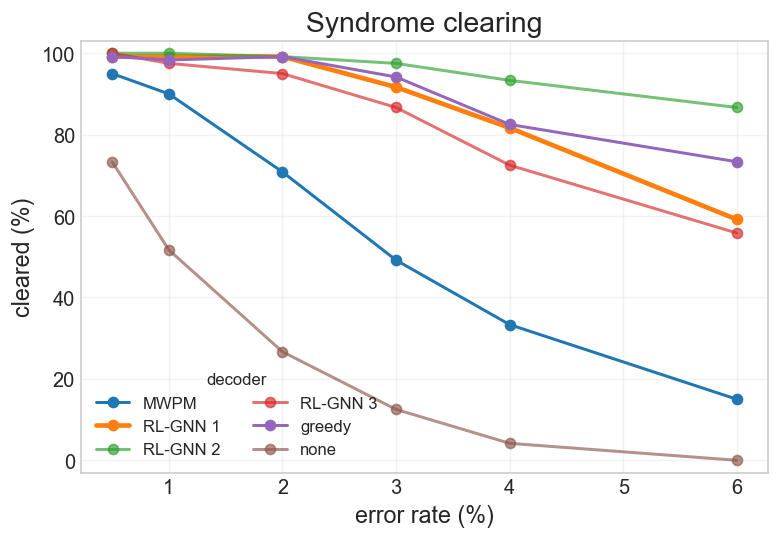

In [175]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for decoder, data in summary.groupby("decoder"):
    lw = 2.8 if decoder == "RL-GNN 1" else 1.8
    alpha = 1.0 if decoder in ["RL-GNN 1", "MWPM", "greedy"] else 0.65
    ax.plot(data["p"] * 100, 100 * data["cleared_rate"], marker="o", linewidth=lw, alpha=alpha, label=decoder)
ax.set_title("Syndrome clearing")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("cleared (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.25)
ax.legend(title="decoder", ncols=2)
plt.tight_layout()
plt.show()


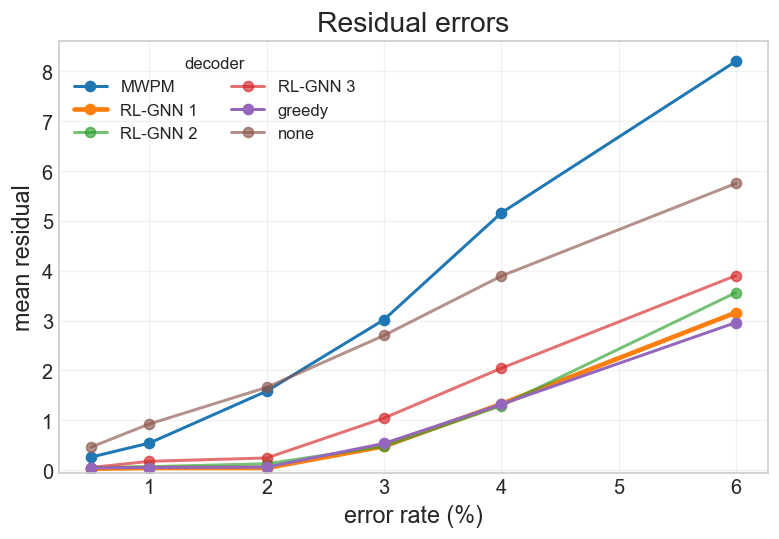

In [176]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for decoder, data in summary.groupby("decoder"):
    lw = 2.8 if decoder == "RL-GNN 1" else 1.8
    alpha = 1.0 if decoder in ["RL-GNN 1", "MWPM", "greedy"] else 0.65
    ax.plot(data["p"] * 100, data["mean_residual"], marker="o", linewidth=lw, alpha=alpha, label=decoder)
ax.set_title("Residual errors")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("mean residual")
ax.set_ylim(bottom=-0.05)
ax.grid(True, alpha=0.25)
ax.legend(title="decoder", ncols=2)
plt.tight_layout()
plt.show()


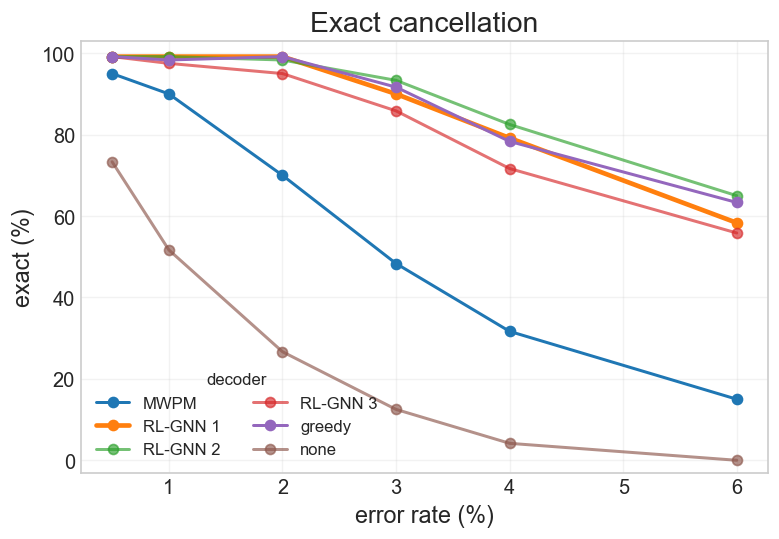

In [177]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for decoder, data in summary.groupby("decoder"):
    lw = 2.8 if decoder == "RL-GNN 1" else 1.8
    alpha = 1.0 if decoder in ["RL-GNN 1", "MWPM", "greedy"] else 0.65
    ax.plot(data["p"] * 100, 100 * data["exact_rate"], marker="o", linewidth=lw, alpha=alpha, label=decoder)
ax.set_title("Exact cancellation")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("exact (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.25)
ax.legend(title="decoder", ncols=2)
plt.tight_layout()
plt.show()


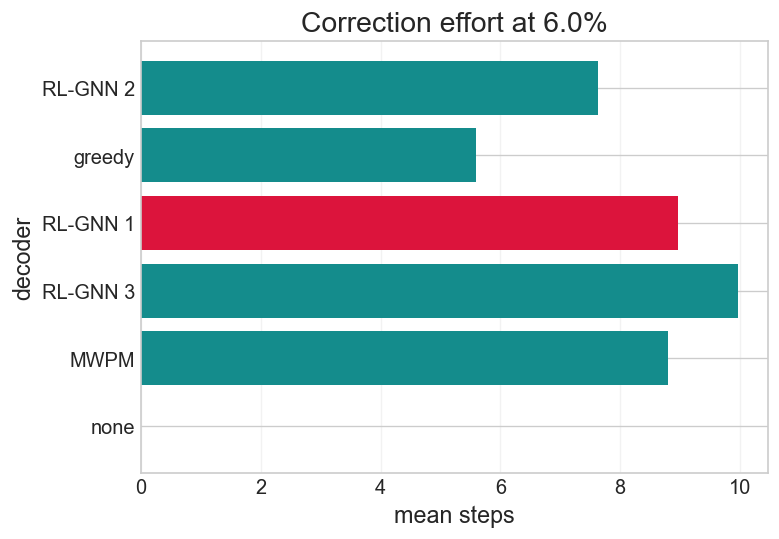

In [178]:
effort = summary[summary["p"] == NOISE_RATES[-1]].sort_values("cleared_rate", ascending=True)
fig, ax = plt.subplots(figsize=(6.6, 4.6))
colors = ["crimson" if d == "RL-GNN 1" else "#148C8C" for d in effort["decoder"]]
ax.barh(effort["decoder"], effort["mean_steps"], color=colors)
ax.set_title(f"Correction effort at {100*NOISE_RATES[-1]:.1f}%")
ax.set_xlabel("mean steps")
ax.set_ylabel("decoder")
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


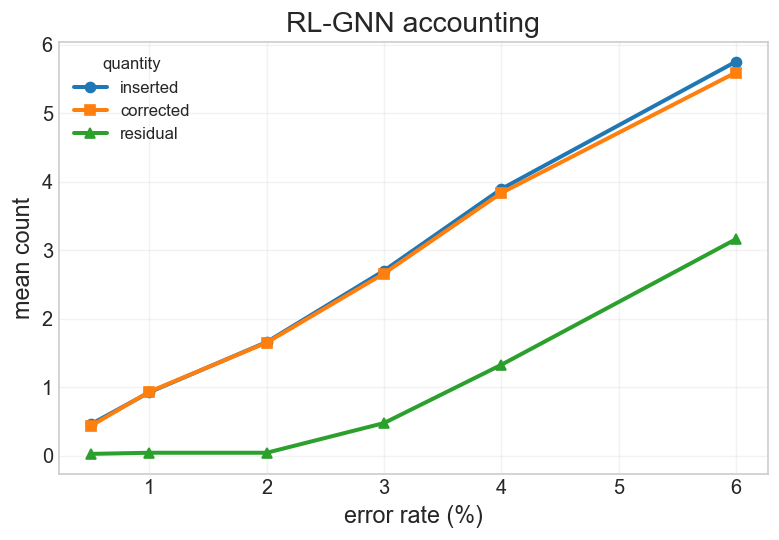

In [179]:
best_trials = all_trials[all_trials["decoder"] == "RL-GNN 1"]
accounting = best_trials.groupby("p", as_index=False).agg(
    inserted=("initial component weight", "mean"),
    corrected=("correction weight", "mean"),
    residual=("residual", "mean"),
)
fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.plot(accounting["p"] * 100, accounting["inserted"], marker="o", linewidth=2.4, label="inserted")
ax.plot(accounting["p"] * 100, accounting["corrected"], marker="s", linewidth=2.4, label="corrected")
ax.plot(accounting["p"] * 100, accounting["residual"], marker="^", linewidth=2.4, label="residual")
ax.set_title("RL-GNN accounting")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("mean count")
ax.grid(True, alpha=0.25)
ax.legend(title="quantity")
plt.tight_layout()
plt.show()


## 8. Fixed-Weight Stress Test

The noise sweep mixes several error weights. This stress test fixes the Pauli error weight directly, making it easier to see where each decoder starts to break down.


In [180]:
def evaluate_fixed_weight(weights, episodes, seed=90_000):
    methods = ["greedy", "MWPM", "RL-GNN 1"]
    rows = []
    sampler = StimCSSSampler(hx, hz, seed=seed)
    for weight in weights:
        for episode in range(episodes):
            x_error, z_error, hx_syndrome, hz_syndrome = sampler.sample_exact_pauli_weight(weight)
            for method in methods:
                bundle = trained_models.get(method)
                x_corr, x_final, x_residual, x_steps, x_false, x_missed = decode_component(
                    method, hz, hz_syndrome, x_error, model_bundle=bundle, component="X", seed=seed + episode
                )
                z_corr, z_final, z_residual, z_steps, z_false, z_missed = decode_component(
                    method, hx, hx_syndrome, z_error, model_bundle=bundle, component="Z", seed=seed + 10_000 + episode
                )
                residual_weight = int(x_residual.sum() + z_residual.sum())
                rows.append({
                    "decoder": method,
                    "weight": weight,
                    "episode": episode,
                    "cleared": int(x_final.sum()) == 0 and int(z_final.sum()) == 0,
                    "exact": residual_weight == 0,
                    "residual": residual_weight,
                    "steps": int(x_steps + z_steps),
                })
    return pd.DataFrame(rows)

fixed_trials = evaluate_fixed_weight(STRESS_ERROR_WEIGHT, STRESS_EPISODES)
fixed_summary = fixed_trials.groupby(["decoder", "weight"], as_index=False).agg(
    cleared_rate=("cleared", "mean"),
    exact_rate=("exact", "mean"),
    mean_residual=("residual", "mean"),
    mean_steps=("steps", "mean"),
)
display(fixed_summary.style.format({"cleared_rate": "{:.1%}", "exact_rate": "{:.1%}", "mean_residual": "{:.2f}", "mean_steps": "{:.2f}"}))


,decoder,weight,cleared_rate,exact_rate,mean_residual,mean_steps
0,MWPM,0,100.0%,100.0%,0.00,0.00
1,MWPM,1,100.0%,100.0%,0.00,1.41
2,MWPM,2,48.8%,46.2%,2.42,4.35
3,MWPM,3,13.8%,11.2%,5.14,6.74
4,MWPM,4,0.0%,0.0%,7.76,9.10
5,MWPM,5,0.0%,0.0%,10.39,10.99
6,MWPM,6,0.0%,0.0%,12.41,12.12
7,MWPM,7,0.0%,0.0%,15.28,13.60
8,MWPM,8,0.0%,0.0%,18.64,15.12
9,RL-GNN 1,0,100.0%,100.0%,0.00,2.00


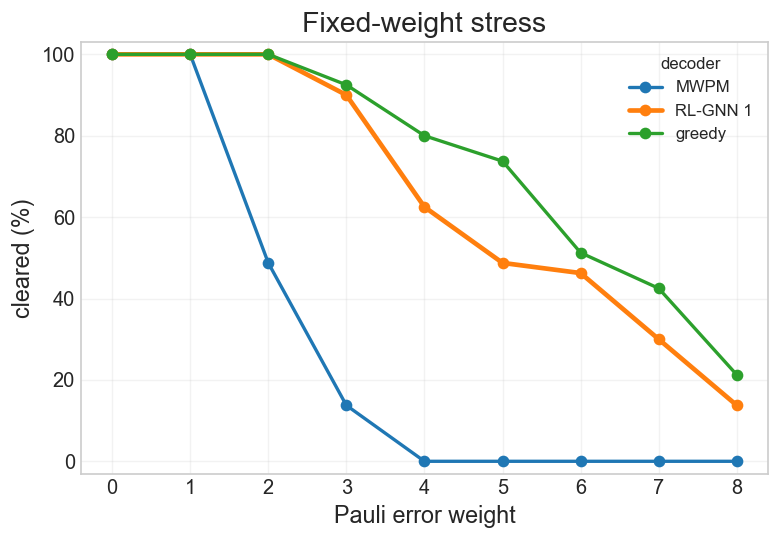

In [181]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for decoder, data in fixed_summary.groupby("decoder"):
    lw = 2.8 if decoder == "RL-GNN 1" else 2.0
    ax.plot(data["weight"], 100 * data["cleared_rate"], marker="o", linewidth=lw, label=decoder)
ax.set_title("Fixed-weight stress")
ax.set_xlabel("Pauli error weight")
ax.set_ylabel("cleared (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.25)
ax.legend(title="decoder")
plt.tight_layout()
plt.show()


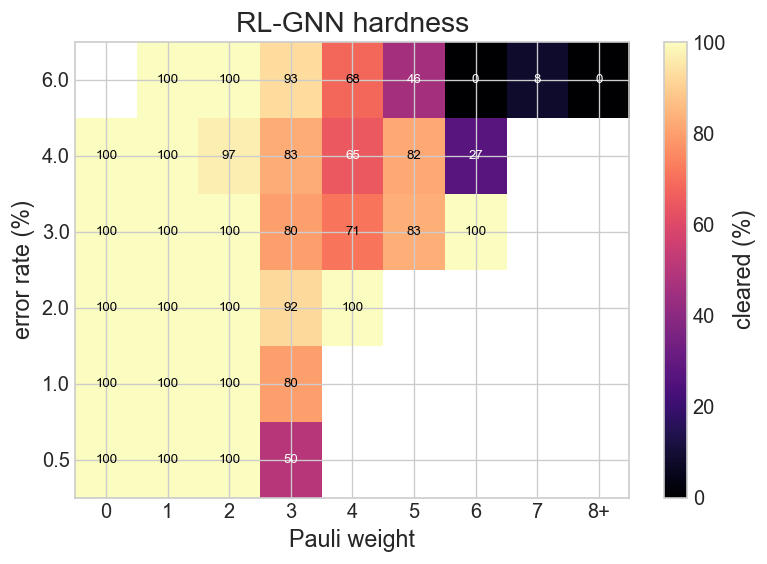

In [182]:
hardness_source = all_trials[all_trials["decoder"] == "RL-GNN 1"].copy()
hardness_source["weight bin"] = hardness_source["pauli weight"].clip(upper=8).astype(int).astype(str)
hardness_source.loc[hardness_source["pauli weight"] >= 8, "weight bin"] = "8+"
hardness = hardness_source.pivot_table(index="p", columns="weight bin", values="cleared", aggfunc="mean", observed=True).sort_index()
ordered_cols = [str(i) for i in range(8)] + ["8+"]
hardness = hardness.reindex(columns=[c for c in ordered_cols if c in hardness.columns])

fig, ax = plt.subplots(figsize=(6.6, 4.8))
image = ax.imshow(100 * hardness.values, origin="lower", aspect="auto", cmap="magma", vmin=0, vmax=100)
ax.set_title("RL-GNN hardness")
ax.set_xlabel("Pauli weight")
ax.set_ylabel("error rate (%)")
ax.set_xticks(range(len(hardness.columns)))
ax.set_xticklabels(hardness.columns)
ax.set_yticks(range(len(hardness.index)))
ax.set_yticklabels([f"{100*p:.1f}" for p in hardness.index])
for i in range(hardness.shape[0]):
    for j in range(hardness.shape[1]):
        value = hardness.values[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{100*value:.0f}", ha="center", va="center", fontsize=8, color="white" if value < 0.65 else "black")
fig.colorbar(image, ax=ax, label="cleared (%)")
plt.tight_layout()
plt.show()


## 9. Representative Episodes

The table below shows a few individual high-noise episodes for the selected RL--GNN model and the baselines.


In [183]:
case_source = all_trials[(all_trials["p"] == NOISE_RATES[-1]) & (all_trials["decoder"].isin(["RL-GNN 1", "MWPM", "greedy"]))].copy()
case_table = (
    case_source
    .sort_values(["episode", "decoder"])
    .head(18)[["episode", "decoder", "pauli weight", "cleared", "exact", "residual", "final syndrome", "steps", "false flips", "missed errors"]]
)
display(case_table)


,episode,decoder,pauli weight,cleared,exact,residual,final syndrome,steps,false flips,missed errors
3602,0,MWPM,2,False,False,2,4,6,2,0
3603,0,RL-GNN 1,2,True,True,0,0,4,0,0
3601,0,greedy,2,True,True,0,0,4,0,0
3608,1,MWPM,3,True,True,0,0,3,0,0
3609,1,RL-GNN 1,3,True,True,0,0,3,0,0
3607,1,greedy,3,True,True,0,0,3,0,0
3614,2,MWPM,5,False,False,16,10,12,10,6
3615,2,RL-GNN 1,5,False,False,6,4,16,2,4
3613,2,greedy,5,True,True,0,0,10,0,0
3620,3,MWPM,5,False,False,13,9,10,8,5


## 10. Larger BB Code: `[[144,12,12]]`

The previous figures used the smaller `[[72,12,6]]` BB code. We now repeat the same type of QEC test on the larger `[[144,12,12]]` BB code, using the same polynomials but a larger lattice with `L=12` and `M=6`. The selected RL--GNN hyperparameters are reused, but the model is retrained on the larger Tanner graph.


In [184]:
L_BIG, M_BIG = 12, 6
hx_big, hz_big = bivariate_bicycle_code(L_BIG, M_BIG)
n_big = hx_big.shape[1]


def gf2_rank(matrix):
    a = np.asarray(matrix, dtype=np.uint8).copy() % 2
    rows, cols = a.shape
    rank = 0
    for col in range(cols):
        pivot = next((row for row in range(rank, rows) if a[row, col]), None)
        if pivot is None:
            continue
        if pivot != rank:
            a[[rank, pivot]] = a[[pivot, rank]]
        for row in range(rows):
            if row != rank and a[row, col]:
                a[row] ^= a[rank]
        rank += 1
        if rank == rows:
            break
    return rank


rank_hx_big = gf2_rank(hx_big.toarray())
rank_hz_big = gf2_rank(hz_big.toarray())
k_big = n_big - rank_hx_big - rank_hz_big

big_code_summary = pd.DataFrame([{
    "code": "[[144,12,12]] BB",
    "L": L_BIG,
    "M": M_BIG,
    "qubits": n_big,
    "X checks": hx_big.shape[0],
    "Z checks": hz_big.shape[0],
    "rank Hx": rank_hx_big,
    "rank Hz": rank_hz_big,
    "k": k_big,
    "distance": 12,
}])
display(big_code_summary)


,code,L,M,qubits,X checks,Z checks,rank Hx,rank Hz,k,distance
0,"[[144,12,12]] BB",12,6,144,72,72,66,66,12,12


### Train the larger-code RL--GNN

The larger code has twice as many physical qubits as the previous test, so the GNN has to operate on a larger Tanner graph. We train only the selected configuration to keep the notebook practical.


In [185]:
def make_stim_component_sampler_for_code(hx_code, hz_code, component, p_error, min_weight, max_weight, seed):
    local_sampler = StimCSSSampler(hx_code, hz_code, seed=seed)
    fallback_rng = np.random.default_rng(seed + 999)

    def sampler(n_qubits, rng):
        for _ in range(300):
            x_error, z_error, _, _ = local_sampler.sample_pauli_error(p_error)
            component_error = x_error if component == "X" else z_error
            weight = int(component_error.sum())
            if weight >= min_weight and weight <= max_weight:
                return component_error.copy()
        return utils.random_component_error(n_qubits, fallback_rng, p=p_error, min_weight=min_weight, max_weight=max_weight)

    return sampler


def make_training_env_for_code(check_matrix, hx_code, hz_code, config, component, seed_offset=0):
    return utils.CSSCorrectionEnv(
        check_matrix,
        max_steps=int(config["max_steps"]),
        error_sampler=make_stim_component_sampler_for_code(
            hx_code,
            hz_code,
            component,
            float(config["p_train"]),
            int(config["min_train_weight"]),
            int(config["max_train_weight"]),
            int(config["seed"]) + seed_offset,
        ),
        p_error=float(config["p_train"]),
        seed=int(config["seed"]) + seed_offset,
        step_penalty=-0.03,
        flip_reward_scale=0.35,
        success_reward=4.0,
        failure_reward=-2.0,
        allow_stop_when_nonzero=False,
    )


def train_component_decoder_for_code(config, check_matrix, hx_code, hz_code, component, seed_offset):
    env = make_training_env_for_code(check_matrix, hx_code, hz_code, config, component, seed_offset=seed_offset)
    model = utils.GraphActorCritic(env.graph, hidden_dim=int(config["hidden_dim"]), num_layers=int(config["layers"])).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=float(config["lr"]))
    lookup = build_min_weight_lookup(check_matrix, max_weight=2)

    start = time.perf_counter()
    imitation = train_exact_imitation(env, model, optimizer, lookup, int(config["imitation_batches"]), int(config["imitation_batch_size"]))
    rl_history = pd.DataFrame(utils.train_actor_critic(
        env,
        model,
        optimizer,
        episodes=int(config["rl_episodes"]),
        gamma=float(config["gamma"]),
        value_coef=float(config["value_coef"]),
        entropy_coef=float(config["entropy_coef"]),
        grad_clip=1.0,
        device=DEVICE,
    ))
    seconds = time.perf_counter() - start
    return model, imitation, rl_history, seconds


In [186]:
big_config = configs[0].copy()
big_config["label"] = "RL-GNN 144"
big_config["max_steps"] = max(int(big_config["max_steps"]), 18)

torch.manual_seed(int(big_config["seed"]) + 144)
np.random.seed(int(big_config["seed"]) + 144)

print(f"Training {big_config['label']}: hidden={big_config['hidden_dim']}, layers={big_config['layers']}, max_steps={big_config['max_steps']}")

big_x_model, big_x_imitation, big_x_rl, big_x_seconds = train_component_decoder_for_code(
    big_config, hz_big, hx_big, hz_big, "X", seed_offset=144_000
)
big_z_model, big_z_imitation, big_z_rl, big_z_seconds = train_component_decoder_for_code(
    big_config, hx_big, hx_big, hz_big, "Z", seed_offset=244_000
)

big_training_summary = pd.DataFrame([{
    "model": big_config["label"],
    "hidden dim": big_config["hidden_dim"],
    "layers": big_config["layers"],
    "max steps": big_config["max_steps"],
    "X train s": big_x_seconds,
    "Z train s": big_z_seconds,
    "X teacher match": big_x_imitation["teacher match"].iloc[-1],
    "Z teacher match": big_z_imitation["teacher match"].iloc[-1],
    "X final RL success": big_x_rl["success"].tail(20).mean(),
    "Z final RL success": big_z_rl["success"].tail(20).mean(),
}])
display(big_training_summary.style.format({
    "X train s": "{:.1f}",
    "Z train s": "{:.1f}",
    "X teacher match": "{:.2f}",
    "Z teacher match": "{:.2f}",
    "X final RL success": "{:.2f}",
    "Z final RL success": "{:.2f}",
}))


Training RL-GNN 144: hidden=48, layers=3, max_steps=18


,model,hidden dim,layers,max steps,X train s,Z train s,X teacher match,Z teacher match,X final RL success,Z final RL success
0,RL-GNN 144,48,3,18,16.2,15.2,0.88,0.91,1.00,0.95


### Evaluate `[[144,12,12]]` QEC Performance

The evaluation below repeats the syndrome-clearing and residual-error tests on the larger code. MWPM is again a projected PyMatching baseline, because the BB check matrix is still not graphlike.


In [187]:
hx_big_mwpm, hx_big_projected = build_projected_mwpm(hx_big)
hz_big_mwpm, hz_big_projected = build_projected_mwpm(hz_big)

def decode_big_component(method, check_matrix, target_syndrome, true_error, component="X", seed=0):
    if method == "none":
        correction = np.zeros(check_matrix.shape[1], dtype=np.uint8)
        final = target_syndrome.copy()
        steps = 0
    elif method == "greedy":
        correction, final, steps = greedy_decode(check_matrix, target_syndrome, int(big_config["max_steps"]))
    elif method == "MWPM":
        matching = hz_big_mwpm if component == "X" else hx_big_mwpm
        correction, final, steps = mwpm_decode(matching, check_matrix, target_syndrome)
    elif method == "RL-GNN 144":
        model = big_x_model if component == "X" else big_z_model
        correction, final, steps = rl_gnn_decode(check_matrix, model, target_syndrome, int(big_config["max_steps"]), seed)
    else:
        raise ValueError(method)
    residual = (true_error + correction) % 2
    return correction, final, residual, steps


def evaluate_big_code(noise_rates, episodes, seed=144_000):
    methods = ["none", "greedy", "MWPM", "RL-GNN 144"]
    rows = []
    for p_error in noise_rates:
        sampler = StimCSSSampler(hx_big, hz_big, seed=seed + int(100_000 * p_error))
        for episode in range(episodes):
            x_error, z_error, hx_syndrome, hz_syndrome = sampler.sample_pauli_error(float(p_error))
            physical_weight = int(np.count_nonzero((x_error + z_error) > 0))
            initial_component_weight = int(x_error.sum() + z_error.sum())
            for method in methods:
                x_corr, x_final, x_residual, x_steps = decode_big_component(
                    method, hz_big, hz_syndrome, x_error, component="X", seed=seed + episode
                )
                z_corr, z_final, z_residual, z_steps = decode_big_component(
                    method, hx_big, hx_syndrome, z_error, component="Z", seed=seed + 10_000 + episode
                )
                residual_weight = int(x_residual.sum() + z_residual.sum())
                rows.append({
                    "decoder": method,
                    "p": float(p_error),
                    "episode": episode,
                    "pauli weight": physical_weight,
                    "initial component weight": initial_component_weight,
                    "cleared": int(x_final.sum()) == 0 and int(z_final.sum()) == 0,
                    "exact": residual_weight == 0,
                    "residual": residual_weight,
                    "final syndrome": int(x_final.sum() + z_final.sum()),
                    "steps": int(x_steps + z_steps),
                    "correction weight": int(x_corr.sum() + z_corr.sum()),
                    "net removed": initial_component_weight - residual_weight,
                })
    return pd.DataFrame(rows)


In [188]:
BIG_EVAL_EPISODES = 90
big_trials = evaluate_big_code(NOISE_RATES, BIG_EVAL_EPISODES)
big_summary = big_trials.groupby(["decoder", "p"], as_index=False).agg(
    episodes=("episode", "count"),
    mean_pauli_weight=("pauli weight", "mean"),
    cleared_rate=("cleared", "mean"),
    exact_rate=("exact", "mean"),
    mean_residual=("residual", "mean"),
    mean_final_syndrome=("final syndrome", "mean"),
    mean_steps=("steps", "mean"),
    mean_correction_weight=("correction weight", "mean"),
    mean_net_removed=("net removed", "mean"),
)

big_trials.to_csv(RESULTS_DIR / "qec_trials_144.csv", index=False)
big_summary.to_csv(RESULTS_DIR / "qec_summary_144.csv", index=False)

display(big_summary.style.format({
    "p": "{:.1%}",
    "mean_pauli_weight": "{:.2f}",
    "cleared_rate": "{:.1%}",
    "exact_rate": "{:.1%}",
    "mean_residual": "{:.2f}",
    "mean_final_syndrome": "{:.2f}",
    "mean_steps": "{:.2f}",
    "mean_correction_weight": "{:.2f}",
    "mean_net_removed": "{:.2f}",
}))


,decoder,p,episodes,mean_pauli_weight,cleared_rate,exact_rate,mean_residual,mean_final_syndrome,mean_steps,mean_correction_weight,mean_net_removed
0,MWPM,0.5%,90,0.67,91.1%,91.1%,0.22,0.36,0.96,0.96,0.60
1,MWPM,1.0%,90,1.53,70.0%,70.0%,1.00,1.51,2.84,2.84,1.09
2,MWPM,2.0%,90,2.82,43.3%,42.2%,3.40,4.33,6.10,6.10,0.57
3,MWPM,3.0%,90,4.10,21.1%,21.1%,6.23,7.21,8.93,8.93,-0.84
4,MWPM,4.0%,90,6.23,6.7%,6.7%,10.64,11.33,13.58,13.58,-2.33
5,MWPM,6.0%,90,9.20,0.0%,0.0%,18.94,16.54,19.47,19.47,-6.69
6,RL-GNN 144,0.5%,90,0.67,100.0%,100.0%,0.00,0.00,2.28,0.82,0.82
7,RL-GNN 144,1.0%,90,1.53,100.0%,100.0%,0.00,0.00,3.07,2.09,2.09
8,RL-GNN 144,2.0%,90,2.82,98.9%,98.9%,0.10,0.03,5.23,3.98,3.87
9,RL-GNN 144,3.0%,90,4.10,94.4%,92.2%,0.67,0.16,8.06,5.61,4.72


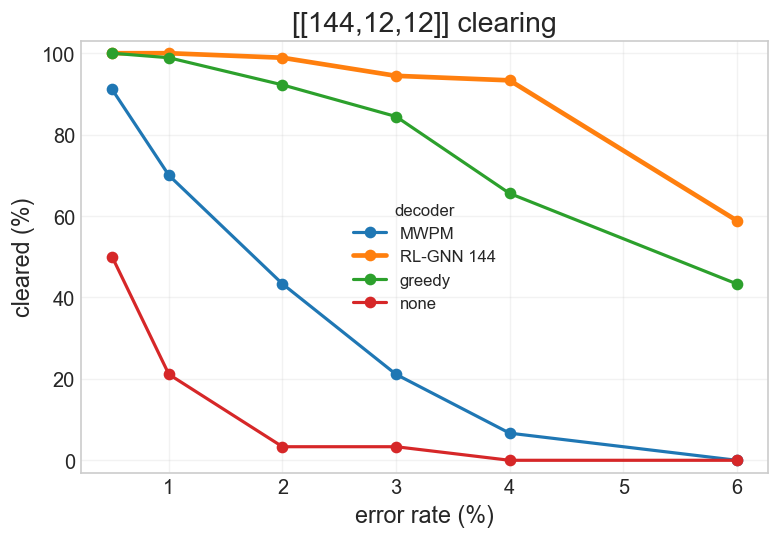

In [189]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for decoder, data in big_summary.groupby("decoder"):
    lw = 2.8 if decoder == "RL-GNN 144" else 1.9
    ax.plot(data["p"] * 100, 100 * data["cleared_rate"], marker="o", linewidth=lw, label=decoder)
ax.set_title("[[144,12,12]] clearing")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("cleared (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.25)
ax.legend(title="decoder")
plt.tight_layout()
plt.show()


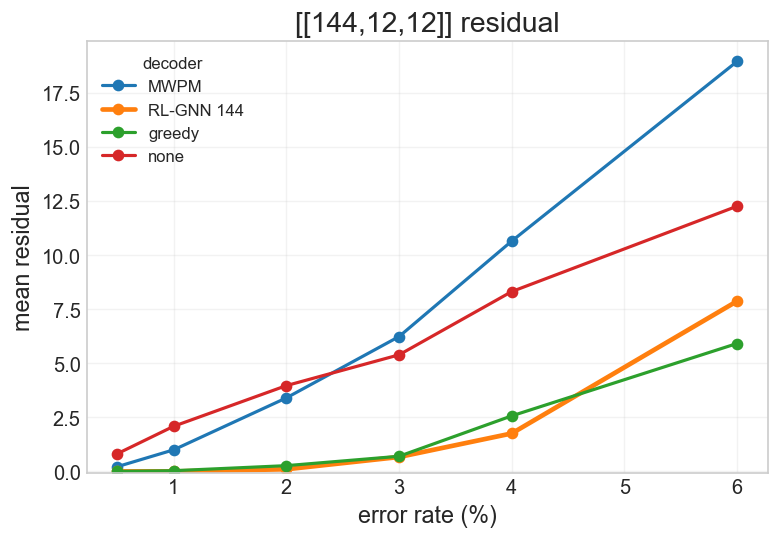

In [190]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for decoder, data in big_summary.groupby("decoder"):
    lw = 2.8 if decoder == "RL-GNN 144" else 1.9
    ax.plot(data["p"] * 100, data["mean_residual"], marker="o", linewidth=lw, label=decoder)
ax.set_title("[[144,12,12]] residual")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("mean residual")
ax.set_ylim(bottom=-0.05)
ax.grid(True, alpha=0.25)
ax.legend(title="decoder")
plt.tight_layout()
plt.show()


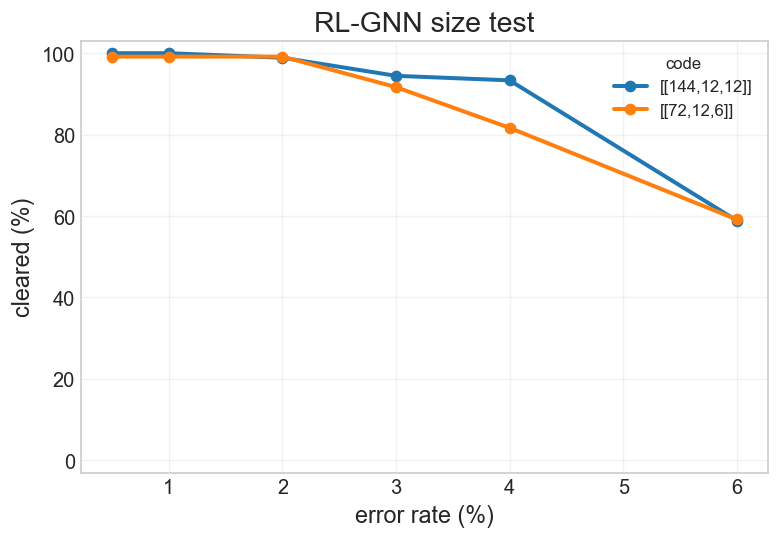

In [191]:
size_compare = pd.concat([
    summary[(summary["decoder"] == "RL-GNN 1")][["p", "cleared_rate"]].assign(code="[[72,12,6]]"),
    big_summary[(big_summary["decoder"] == "RL-GNN 144")][["p", "cleared_rate"]].assign(code="[[144,12,12]]"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(6.6, 4.6))
for code_name, data in size_compare.groupby("code"):
    ax.plot(data["p"] * 100, 100 * data["cleared_rate"], marker="o", linewidth=2.4, label=code_name)
ax.set_title("RL-GNN size test")
ax.set_xlabel("error rate (%)")
ax.set_ylabel("cleared (%)")
ax.set_ylim(-3, 103)
ax.grid(True, alpha=0.25)
ax.legend(title="code")
plt.tight_layout()
plt.show()


## 11. Reading the Results

The main QEC metric here is syndrome clearing. Exact cancellation and residual weight are simulation diagnostics because the sampled error is known; they are stricter than logical success for a degenerate code. The MWPM curve should also be read as a graph-projected PyMatching baseline, not as a native BB-code MWPM decoder. The notebook tests both the smaller `[[72,12,6]]` BB code and the larger `[[144,12,12]]` BB code, using the same polynomial family.


In [228]:
@torch.no_grad()
def measure_agent_certainty(
    hx_code,
    hz_code,
    x_model,
    z_model,
    config,
    code_label,
    error_rates,
    samples=250,
    seed=7000,
):
    """
    Measure how certain the RL-GNN policy is on fresh Stim-sampled syndromes.

    Certainty is measured as the largest action probability:
        max_a pi(a | syndrome)

    This is not a QEC success metric. It measures how decisive the policy is
    when choosing an action.
    """

    rows = []

    for p_error in error_rates:
        sampler = StimCSSSampler(hx_code, hz_code, seed=seed + int(100000 * p_error))

        for sample in range(samples):
            x_error, z_error, hx_syndrome, hz_syndrome = sampler.sample_pauli_error(float(p_error))

            component_data = [
                ("X", hz_code, x_model, hz_syndrome),
                ("Z", hx_code, z_model, hx_syndrome),
            ]

            for component, check_matrix, model, target_syndrome in component_data:
                h = utils.to_csr_binary(check_matrix)

                env = utils.CSSCorrectionEnv(
                    h,
                    max_steps=int(config["max_steps"]),
                    seed=seed + sample,
                    allow_stop_when_nonzero=False,
                )

                env.error = np.zeros(h.shape[1], dtype=np.uint8)
                env.correction = np.zeros(h.shape[1], dtype=np.uint8)
                env.syndrome = target_syndrome.copy().astype(np.uint8)

                logits, value = model(
                    env.node_features(DEVICE),
                    env.action_mask(DEVICE),
                )

                probs = torch.softmax(logits, dim=0)
                chosen_action = int(torch.argmax(probs).item())
                confidence = float(probs[chosen_action].detach().cpu())

                rows.append({
                    "code": code_label,
                    "error_rate": float(p_error),
                    "component": component,
                    "sample": sample,
                    "syndrome_weight": int(target_syndrome.sum()),
                    "confidence": confidence,
                    "value_estimate": float(value.detach().cpu()),
                    "chosen_stop": chosen_action == env.stop_action,
                })

    return pd.DataFrame(rows)


certainty_72 = measure_agent_certainty(
    hx,
    hz,
    trained_models["RL-GNN 1"]["x_model"],
    trained_models["RL-GNN 1"]["z_model"],
    trained_models["RL-GNN 1"]["config"],
    code_label="[[72,12,6]]",
    error_rates=NOISE_RATES,
    samples=250,
    seed=7100,
)

certainty_144 = measure_agent_certainty(
    hx_big,
    hz_big,
    big_x_model,
    big_z_model,
    big_config,
    code_label="[[144,12,12]]",
    error_rates=NOISE_RATES,
    samples=250,
    seed=8100,
)

certainty_data = pd.concat([certainty_72, certainty_144], ignore_index=True)

display(certainty_data.head())

display(
    certainty_data
    .groupby(["code", "error_rate"], as_index=False)
    .agg(
        mean_confidence=("confidence", "mean"),
        median_confidence=("confidence", "median"),
        mean_value=("value_estimate", "mean"),
        stop_rate=("chosen_stop", "mean"),
        mean_syndrome_weight=("syndrome_weight", "mean"),
    )
    .style.format({
        "error_rate": "{:.1%}",
        "mean_confidence": "{:.2f}",
        "median_confidence": "{:.2f}",
        "mean_value": "{:.2f}",
        "stop_rate": "{:.1%}",
        "mean_syndrome_weight": "{:.2f}",
    })
)


KeyboardInterrupt: 

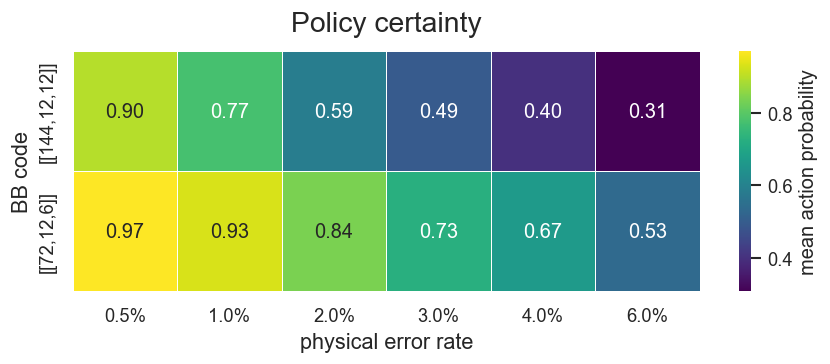

In [229]:
import seaborn as sns

certainty_heatmap = (
    certainty_data
    .groupby(["code", "error_rate"], as_index=False)
    .agg(mean_confidence=("confidence", "mean"))
    .pivot(index="code", columns="error_rate", values="mean_confidence")
)

certainty_heatmap.columns = [f"{100*p:.1f}%" for p in certainty_heatmap.columns]

fig, ax = plt.subplots(figsize=(7.4, 3.2))

sns.heatmap(
    certainty_heatmap,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "mean action probability"},
    ax=ax,
)

ax.set_title("Policy certainty", fontsize=17, pad=12)
ax.set_xlabel("physical error rate", fontsize=13)
ax.set_ylabel("BB code", fontsize=13)

plt.tight_layout()
plt.show()


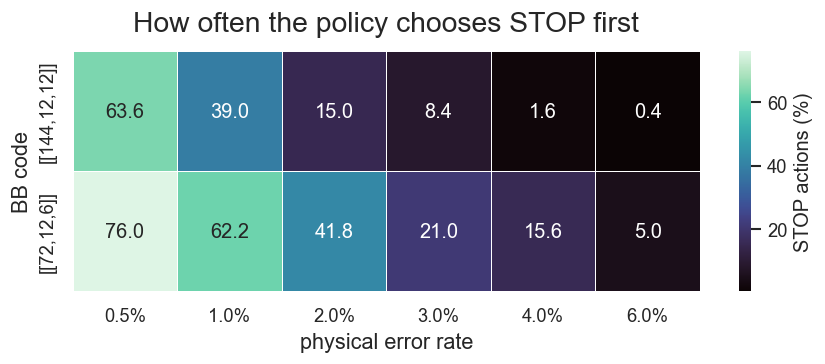

In [224]:
stop_heatmap = (
    certainty_data
    .groupby(["code", "error_rate"], as_index=False)
    .agg(stop_rate=("chosen_stop", "mean"))
    .pivot(index="code", columns="error_rate", values="stop_rate")
)

stop_heatmap.columns = [f"{100*p:.1f}%" for p in stop_heatmap.columns]

fig, ax = plt.subplots(figsize=(7.4, 3.2))

sns.heatmap(
    100 * stop_heatmap,
    annot=True,
    fmt=".1f",
    cmap="mako",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "STOP actions (%)"},
    ax=ax,
)

ax.set_title("How often the policy chooses STOP first", fontsize=17, pad=12)
ax.set_xlabel("physical error rate", fontsize=13)
ax.set_ylabel("BB code", fontsize=13)

plt.tight_layout()
plt.show()


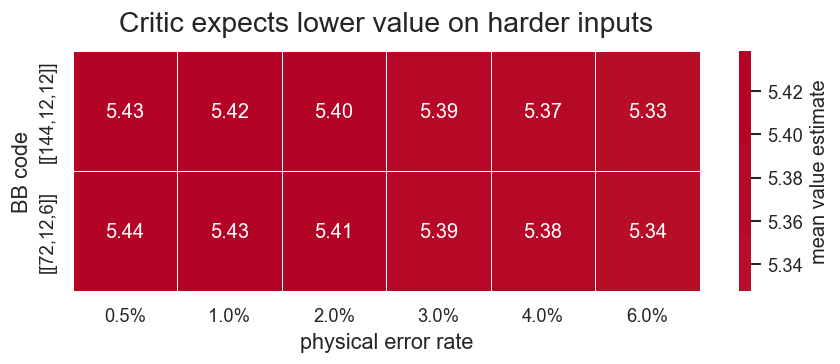

In [225]:
value_heatmap = (
    certainty_data
    .groupby(["code", "error_rate"], as_index=False)
    .agg(mean_value=("value_estimate", "mean"))
    .pivot(index="code", columns="error_rate", values="mean_value")
)

value_heatmap.columns = [f"{100*p:.1f}%" for p in value_heatmap.columns]

fig, ax = plt.subplots(figsize=(7.4, 3.2))

sns.heatmap(
    value_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "mean value estimate"},
    ax=ax,
)

ax.set_title("Critic expects lower value on harder inputs", fontsize=17, pad=12)
ax.set_xlabel("physical error rate", fontsize=13)
ax.set_ylabel("BB code", fontsize=13)

plt.tight_layout()
plt.show()


**Comparison with different policy neural networks for the same BB code**

In [233]:
import types

def make_ffnn_actor_critic(env, hidden_dim=128):
    """
    No-class RL+FFNN baseline.

    It flattens the QEC environment node features and predicts:
    - action logits
    - critic value
    """

    node_features = env.node_features(DEVICE)
    input_dim = int(node_features.numel())
    feature_dim = int(node_features.shape[1])
    num_actions = int(env.n_actions)

    shared = torch.nn.Sequential(
        torch.nn.Linear(input_dim, hidden_dim),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_dim, hidden_dim),
        torch.nn.ReLU(),
    )

    actor = torch.nn.Linear(hidden_dim, num_actions)
    critic = torch.nn.Linear(hidden_dim, 1)

    model = torch.nn.Module()
    model.shared = shared
    model.actor = actor
    model.critic = critic

    def forward(self, node_features, action_mask=None):
        x = node_features.flatten().float()
        h = self.shared(x)

        logits = self.actor(h)
        value = self.critic(h).squeeze(-1)

        if action_mask is not None:
            logits = logits.masked_fill(~action_mask.bool(), -1e9)

        return logits, value

    @torch.no_grad()
    def greedy_action(self, node_features, action_mask=None):
        logits, _ = self.forward(node_features, action_mask)
        return int(torch.argmax(logits).item())

    model.forward = types.MethodType(forward, model)
    model.greedy_action = types.MethodType(greedy_action, model)

    return model.to(DEVICE)


def make_cnn_actor_critic(env, hidden_dim=64):
    """
    No-class RL+CNN baseline.

    It treats the node-feature matrix as a 1D signal over Tanner-graph nodes.
    It does not explicitly use graph edges.
    """

    node_features = env.node_features(DEVICE)
    feature_dim = int(node_features.shape[1])
    num_actions = int(env.n_actions)

    encoder = torch.nn.Sequential(
        torch.nn.Conv1d(feature_dim, hidden_dim, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.Conv1d(hidden_dim, hidden_dim, kernel_size=5, padding=2),
        torch.nn.ReLU(),
        torch.nn.AdaptiveAvgPool1d(1),
    )

    actor = torch.nn.Linear(hidden_dim, num_actions)
    critic = torch.nn.Linear(hidden_dim, 1)

    model = torch.nn.Module()
    model.encoder = encoder
    model.actor = actor
    model.critic = critic

    def forward(self, node_features, action_mask=None):
        x = node_features.float().T.unsqueeze(0)
        h = self.encoder(x).squeeze(0).squeeze(-1)

        logits = self.actor(h)
        value = self.critic(h).squeeze(-1)

        if action_mask is not None:
            logits = logits.masked_fill(~action_mask.bool(), -1e9)

        return logits, value

    @torch.no_grad()
    def greedy_action(self, node_features, action_mask=None):
        logits, _ = self.forward(node_features, action_mask)
        return int(torch.argmax(logits).item())

    model.forward = types.MethodType(forward, model)
    model.greedy_action = types.MethodType(greedy_action, model)

    return model.to(DEVICE)


In [234]:
def create_policy_model_no_class(model_type, env, hidden_dim=64):
    """
    Create one of three RL actor-critic policies.

    RL+GNN:
        Uses Tanner-graph message passing.

    RL+FFNN:
        Uses flattened node features only.

    RL+CNN:
        Uses 1D convolutions over the node-feature sequence.
    """

    if model_type == "RL+GNN":
        return utils.GraphActorCritic(
            env.graph,
            hidden_dim=hidden_dim,
            num_layers=3,
        ).to(DEVICE)

    if model_type == "RL+FFNN":
        return make_ffnn_actor_critic(
            env,
            hidden_dim=2 * hidden_dim,
        )

    if model_type == "RL+CNN":
        return make_cnn_actor_critic(
            env,
            hidden_dim=hidden_dim,
        )

    raise ValueError(model_type)


In [235]:
def train_architecture_baseline_no_class(model_type, check_matrix, component="X", seed=123):
    """
    Train RL+GNN, RL+FFNN, or RL+CNN under the same QEC environment.
    """

    config = configs[0].copy()
    config["hidden_dim"] = 64
    config["layers"] = 3
    config["imitation_batches"] = 30
    config["imitation_batch_size"] = 16
    config["rl_episodes"] = 80
    config["max_steps"] = 12
    config["seed"] = seed

    env = make_training_env(check_matrix, config, component, seed_offset=seed)
    model = create_policy_model_no_class(model_type, env, hidden_dim=config["hidden_dim"])

    optimizer = torch.optim.Adam(model.parameters(), lr=float(config["lr"]))
    lookup = build_min_weight_lookup(check_matrix, max_weight=2)

    start = time.perf_counter()

    guide_history = train_exact_imitation(
        env,
        model,
        optimizer,
        lookup,
        batches=config["imitation_batches"],
        batch_size=config["imitation_batch_size"],
    )

    reward_history = pd.DataFrame(utils.train_actor_critic(
        env,
        model,
        optimizer,
        episodes=config["rl_episodes"],
        gamma=float(config["gamma"]),
        value_coef=float(config["value_coef"]),
        entropy_coef=float(config["entropy_coef"]),
        grad_clip=1.0,
        device=DEVICE,
    ))

    train_seconds = time.perf_counter() - start

    return model, config, guide_history, reward_history, train_seconds


architecture_models = {}
architecture_logs = []

for i, model_type in enumerate(["RL+GNN", "RL+FFNN", "RL+CNN"]):
    print(f"Training {model_type}")

    model, config, guide_history, reward_history, train_seconds = train_architecture_baseline_no_class(
        model_type,
        check_matrix=hz,
        component="X",
        seed=30_000 + i,
    )

    architecture_models[model_type] = {
        "model": model,
        "config": config,
        "guide_history": guide_history,
        "reward_history": reward_history,
        "train_seconds": train_seconds,
    }

    architecture_logs.append({
        "model": model_type,
        "train seconds": train_seconds,
        "guide match": guide_history["teacher match"].tail(10).mean(),
        "reward success": reward_history["success"].tail(20).mean(),
    })

architecture_training_summary = pd.DataFrame(architecture_logs)

display(
    architecture_training_summary.style.format({
        "train seconds": "{:.1f}",
        "guide match": "{:.2f}",
        "reward success": "{:.2f}",
    })
)


Training RL+GNN
Training RL+FFNN
Training RL+CNN


,model,train seconds,guide match,reward success
0,RL+GNN,12.1,0.90,0.95
1,RL+FFNN,3.7,0.03,0.00
2,RL+CNN,5.3,0.02,0.00


In [236]:
@torch.no_grad()
def evaluate_architecture_policy(
    model,
    config,
    check_matrix,
    component="X",
    error_rates=(0.01, 0.03, 0.06),
    episodes=250,
    seed=55_000,
):
    """
    Evaluate one trained RL policy architecture on fresh QEC syndromes.
    """

    rows = []

    for p_error in error_rates:
        sampler = StimCSSSampler(hx, hz, seed=seed + int(100_000 * p_error))

        for episode in range(episodes):
            x_error, z_error, hx_syndrome, hz_syndrome = sampler.sample_pauli_error(float(p_error))

            if component == "X":
                target_error = x_error
                target_syndrome = hz_syndrome
            else:
                target_error = z_error
                target_syndrome = hx_syndrome

            correction, final_syndrome, steps = rl_gnn_decode(
                check_matrix=check_matrix,
                model=model,
                target_syndrome=target_syndrome,
                max_steps=int(config["max_steps"]),
                seed=seed + episode,
            )

            residual = (target_error + correction) % 2

            # Initial-state policy certainty.
            h = utils.to_csr_binary(check_matrix)
            env = utils.CSSCorrectionEnv(
                h,
                max_steps=int(config["max_steps"]),
                seed=seed + episode,
                allow_stop_when_nonzero=False,
            )

            env.error = np.zeros(h.shape[1], dtype=np.uint8)
            env.correction = np.zeros(h.shape[1], dtype=np.uint8)
            env.syndrome = target_syndrome.copy().astype(np.uint8)

            logits, value = model(
                env.node_features(DEVICE),
                env.action_mask(DEVICE),
            )

            probs = torch.softmax(logits, dim=0)
            certainty = float(probs.max().detach().cpu())

            rows.append({
                "model": None,
                "p_error": float(p_error),
                "episode": episode,
                "initial_syndrome": int(target_syndrome.sum()),
                "cleared": int(final_syndrome.sum()) == 0,
                "residual": int(residual.sum()),
                "steps": int(steps),
                "correction_weight": int(correction.sum()),
                "certainty": certainty,
                "value": float(value.detach().cpu()),
            })

    return pd.DataFrame(rows)


ARCHITECTURE_ERROR_RATES = [0.01, 0.03, 0.06]
ARCHITECTURE_EPISODES = 250

architecture_eval_frames = []

for i, (model_type, bundle) in enumerate(architecture_models.items()):
    eval_df = evaluate_architecture_policy(
        model=bundle["model"],
        config=bundle["config"],
        check_matrix=hz,
        component="X",
        error_rates=ARCHITECTURE_ERROR_RATES,
        episodes=ARCHITECTURE_EPISODES,
        seed=70_000 + 1_000 * i,
    )

    eval_df["model"] = model_type
    architecture_eval_frames.append(eval_df)

architecture_eval = pd.concat(architecture_eval_frames, ignore_index=True)

architecture_summary = (
    architecture_eval
    .groupby(["model", "p_error"], as_index=False)
    .agg(
        cleared_rate=("cleared", "mean"),
        mean_residual=("residual", "mean"),
        mean_steps=("steps", "mean"),
        mean_correction_weight=("correction_weight", "mean"),
        mean_certainty=("certainty", "mean"),
        mean_value=("value", "mean"),
        mean_initial_syndrome=("initial_syndrome", "mean"),
    )
)

architecture_overall = (
    architecture_summary
    .groupby("model", as_index=False)
    .agg(
        avg_cleared=("cleared_rate", "mean"),
        avg_residual=("mean_residual", "mean"),
        avg_steps=("mean_steps", "mean"),
        avg_certainty=("mean_certainty", "mean"),
        avg_value=("mean_value", "mean"),
    )
    .merge(
        architecture_training_summary,
        on="model",
        how="left",
    )
    .sort_values("avg_cleared", ascending=False)
)

display(
    architecture_overall.style.format({
        "avg_cleared": "{:.1%}",
        "avg_residual": "{:.2f}",
        "avg_steps": "{:.2f}",
        "avg_certainty": "{:.2f}",
        "avg_value": "{:.2f}",
        "train seconds": "{:.1f}",
        "guide match": "{:.2f}",
        "reward success": "{:.2f}",
    })
)

display(
    architecture_summary.style.format({
        "p_error": "{:.1%}",
        "cleared_rate": "{:.1%}",
        "mean_residual": "{:.2f}",
        "mean_steps": "{:.2f}",
        "mean_correction_weight": "{:.2f}",
        "mean_certainty": "{:.2f}",
        "mean_value": "{:.2f}",
        "mean_initial_syndrome": "{:.2f}",
    })
)


,model,avg_cleared,avg_residual,avg_steps,avg_certainty,avg_value,train seconds,guide match,reward success
2,RL+GNN,100.0%,0.60,2.03,0.76,5.10,12.1,0.90,0.95
1,RL+FFNN,32.5%,2.85,8.43,0.36,-4.46,3.7,0.03,0.00
0,RL+CNN,31.2%,1.54,8.57,0.34,-3.91,5.3,0.02,0.00


,model,p_error,cleared_rate,mean_residual,mean_steps,mean_correction_weight,mean_certainty,mean_value,mean_initial_syndrome
0,RL+CNN,1.0%,63.2%,0.46,5.05,0.01,0.64,-3.90,1.33
1,RL+CNN,3.0%,24.4%,1.43,9.32,0.00,0.28,-3.91,3.89
2,RL+CNN,6.0%,6.0%,2.73,11.34,0.00,0.11,-3.92,6.75
3,RL+FFNN,1.0%,69.2%,0.98,4.39,0.61,0.71,-4.49,1.20
4,RL+FFNN,3.0%,23.6%,2.88,9.42,1.53,0.27,-4.47,4.06
5,RL+FFNN,6.0%,4.8%,4.68,11.47,1.81,0.10,-4.44,7.38
6,RL+GNN,1.0%,100.0%,0.00,1.06,0.41,0.96,5.20,1.20
7,RL+GNN,3.0%,100.0%,0.30,1.83,1.49,0.76,5.12,3.82
8,RL+GNN,6.0%,100.0%,1.50,3.19,3.09,0.54,4.99,7.21


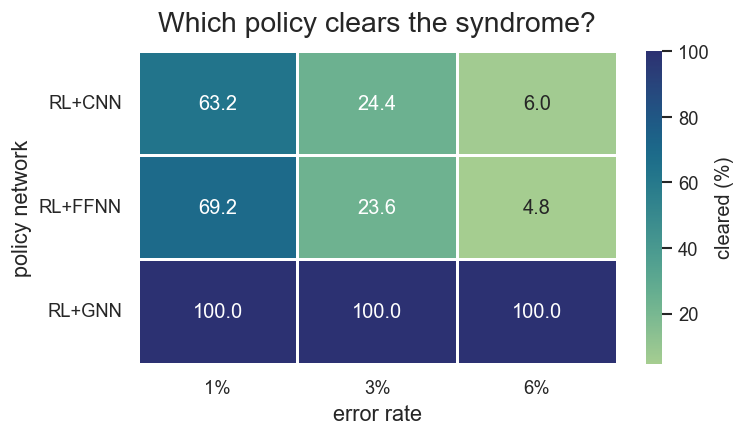

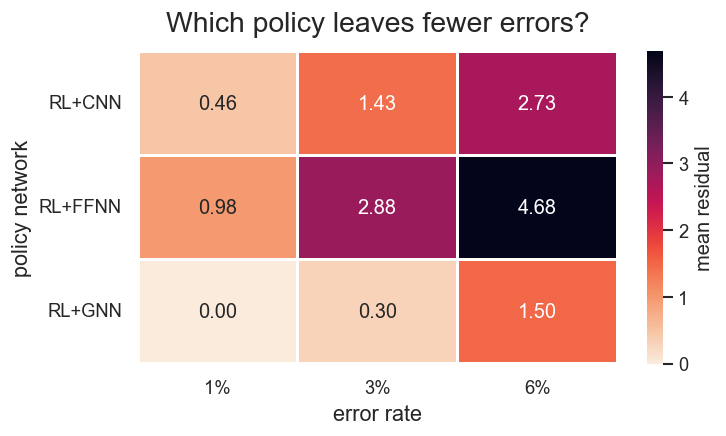

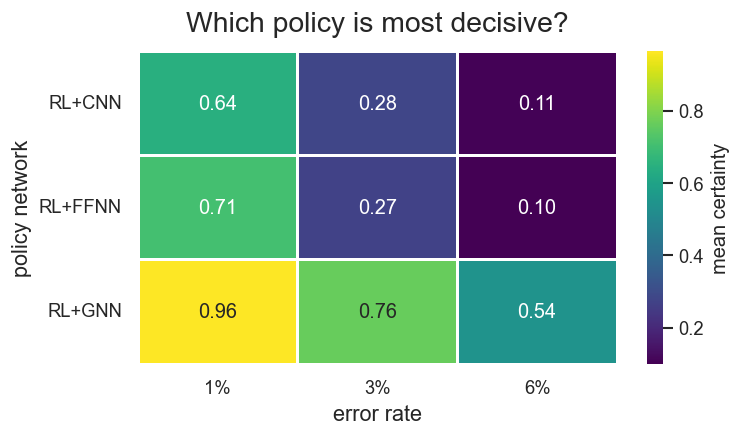

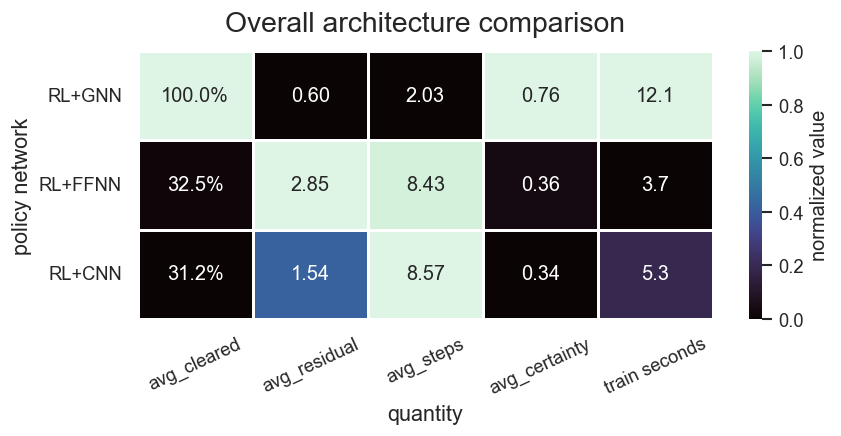

In [237]:
import seaborn as sns

sns.set_theme(style="white")

# 1. Syndrome-clearing heatmap.
cleared_table = (
    architecture_summary
    .pivot(index="model", columns="p_error", values="cleared_rate")
)
cleared_table.columns = [f"{100*p:.0f}%" for p in cleared_table.columns]

fig, ax = plt.subplots(figsize=(6.4, 3.8))
sns.heatmap(
    100 * cleared_table,
    annot=True,
    fmt=".1f",
    cmap="crest",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "cleared (%)"},
    ax=ax,
)
ax.set_title("Which policy clears the syndrome?", fontsize=17, pad=12)
ax.set_xlabel("error rate", fontsize=13)
ax.set_ylabel("policy network", fontsize=13)
ax.tick_params(axis="x", labelrotation=0)
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()


# 2. Residual-error heatmap.
residual_table = (
    architecture_summary
    .pivot(index="model", columns="p_error", values="mean_residual")
)
residual_table.columns = [f"{100*p:.0f}%" for p in residual_table.columns]

fig, ax = plt.subplots(figsize=(6.4, 3.8))
sns.heatmap(
    residual_table,
    annot=True,
    fmt=".2f",
    cmap="rocket_r",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "mean residual"},
    ax=ax,
)
ax.set_title("Which policy leaves fewer errors?", fontsize=17, pad=12)
ax.set_xlabel("error rate", fontsize=13)
ax.set_ylabel("policy network", fontsize=13)
ax.tick_params(axis="x", labelrotation=0)
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()


# 3. Policy-certainty heatmap.
certainty_table = (
    architecture_summary
    .pivot(index="model", columns="p_error", values="mean_certainty")
)
certainty_table.columns = [f"{100*p:.0f}%" for p in certainty_table.columns]

fig, ax = plt.subplots(figsize=(6.4, 3.8))
sns.heatmap(
    certainty_table,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "mean certainty"},
    ax=ax,
)
ax.set_title("Which policy is most decisive?", fontsize=17, pad=12)
ax.set_xlabel("error rate", fontsize=13)
ax.set_ylabel("policy network", fontsize=13)
ax.tick_params(axis="x", labelrotation=0)
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()


# 4. Compact overall comparison heatmap.
overall_metrics = architecture_overall.set_index("model")[
    [
        "avg_cleared",
        "avg_residual",
        "avg_steps",
        "avg_certainty",
        "train seconds",
    ]
].copy()

# Normalize only for color. Annotate with real values.
normalized = overall_metrics.copy()
for column in normalized.columns:
    values = normalized[column].astype(float)
    if values.max() > values.min():
        normalized[column] = (values - values.min()) / (values.max() - values.min())
    else:
        normalized[column] = 0.5

annotation = overall_metrics.copy()
annotation["avg_cleared"] = (100 * annotation["avg_cleared"]).map(lambda v: f"{v:.1f}%")
annotation["avg_residual"] = annotation["avg_residual"].map(lambda v: f"{v:.2f}")
annotation["avg_steps"] = annotation["avg_steps"].map(lambda v: f"{v:.2f}")
annotation["avg_certainty"] = annotation["avg_certainty"].map(lambda v: f"{v:.2f}")
annotation["train seconds"] = annotation["train seconds"].map(lambda v: f"{v:.1f}")

fig, ax = plt.subplots(figsize=(7.4, 3.8))
sns.heatmap(
    normalized,
    annot=annotation,
    fmt="",
    cmap="mako",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "normalized value"},
    ax=ax,
)
ax.set_title("Overall architecture comparison", fontsize=17, pad=12)
ax.set_xlabel("quantity", fontsize=13)
ax.set_ylabel("policy network", fontsize=13)
ax.tick_params(axis="x", labelrotation=25)
ax.tick_params(axis="y", labelrotation=0)
plt.tight_layout()
plt.show()


In [239]:
# Detailed architecture comparison table.
# Task: [[72,12,6]] BB-code X-component decoding using Hz.

residual_by_rate = (
    architecture_summary
    .pivot(index="model", columns="p_error", values="mean_residual")
    .rename(columns={
        0.01: "residual_1pct",
        0.03: "residual_3pct",
        0.06: "residual_6pct",
    })
    .reset_index()
)

cleared_by_rate = (
    architecture_summary
    .pivot(index="model", columns="p_error", values="cleared_rate")
    .rename(columns={
        0.01: "cleared_1pct",
        0.03: "cleared_3pct",
        0.06: "cleared_6pct",
    })
    .reset_index()
)

architecture_detailed_table = (
    architecture_summary
    .groupby("model", as_index=False)
    .agg(
        mean_cleared=("cleared_rate", "mean"),
        mean_residual=("mean_residual", "mean"),
        mean_steps=("mean_steps", "mean"),
        mean_correction_weight=("mean_correction_weight", "mean"),
        mean_certainty=("mean_certainty", "mean"),
        mean_value=("mean_value", "mean"),
        mean_initial_syndrome=("mean_initial_syndrome", "mean"),
    )
    .merge(residual_by_rate, on="model", how="left")
    .merge(cleared_by_rate, on="model", how="left")
    .merge(architecture_training_summary, on="model", how="left")
)

architecture_detailed_table["input"] = architecture_detailed_table["model"].map({
    "RL+GNN": "Tanner graph",
    "RL+FFNN": "flattened nodes",
    "RL+CNN": "1D node sequence",
})

architecture_detailed_table = architecture_detailed_table[
    [
        "model",
        "input",
        "mean_cleared",
        "cleared_1pct",
        "cleared_3pct",
        "cleared_6pct",
        "mean_residual",
        "residual_1pct",
        "residual_3pct",
        "residual_6pct",
        "mean_steps",
        "mean_correction_weight",
        "mean_certainty",
        "mean_value",
        "mean_initial_syndrome",
        "train seconds",
        "reward success",
    ]
].sort_values("mean_residual")

display(
    architecture_detailed_table.style.format({
        "mean_cleared": "{:.1%}",
        "cleared_1pct": "{:.1%}",
        "cleared_3pct": "{:.1%}",
        "cleared_6pct": "{:.1%}",
        "mean_residual": "{:.2f}",
        "residual_1pct": "{:.2f}",
        "residual_3pct": "{:.2f}",
        "residual_6pct": "{:.2f}",
        "mean_steps": "{:.2f}",
        "mean_correction_weight": "{:.2f}",
        "mean_certainty": "{:.2f}",
        "mean_value": "{:.2f}",
        "mean_initial_syndrome": "{:.2f}",
        "train seconds": "{:.1f}",
        "reward success": "{:.2f}",
    })
)

# Shorter LaTeX table for Overleaf.
latex_table = architecture_detailed_table[
    [
        "model",
        "input",
        "mean_cleared",
        "mean_residual",
        "residual_1pct",
        "residual_3pct",
        "residual_6pct",
        "mean_steps",
        "mean_certainty",
        "train seconds",
    ]
].copy()

latex_table = latex_table.rename(columns={
    "model": "Policy",
    "input": "Input",
    "mean_cleared": "Cleared",
    "mean_residual": "Residual",
    "residual_1pct": "Res. 1\\%",
    "residual_3pct": "Res. 3\\%",
    "residual_6pct": "Res. 6\\%",
    "mean_steps": "Steps",
    "mean_certainty": "Certainty",
    "train seconds": "Train (s)",
})

latex_code = latex_table.to_latex(
    index=False,
    escape=False,
    float_format="%.2f",
    caption=(
        "Comparison of RL policy architectures on the "
        "$[[72,12,6]]$ BB-code X-component decoding task."
    ),
    label="tab:rl_architecture_comparison",
)

print(latex_code)


,model,input,mean_cleared,cleared_1pct,cleared_3pct,cleared_6pct,mean_residual,residual_1pct,residual_3pct,residual_6pct,mean_steps,mean_correction_weight,mean_certainty,mean_value,mean_initial_syndrome,train seconds,reward success
2,RL+GNN,Tanner graph,100.0%,100.0%,100.0%,100.0%,0.60,0.00,0.30,1.50,2.03,1.66,0.76,5.10,4.07,12.1,0.95
0,RL+CNN,1D node sequence,31.2%,63.2%,24.4%,6.0%,1.54,0.46,1.43,2.73,8.57,0.01,0.34,-3.91,3.99,5.3,0.00
1,RL+FFNN,flattened nodes,32.5%,69.2%,23.6%,4.8%,2.85,0.98,2.88,4.68,8.43,1.32,0.36,-4.46,4.21,3.7,0.00


\begin{table}
\caption{Comparison of RL policy architectures on the $[[72,12,6]]$ BB-code X-component decoding task.}
\label{tab:rl_architecture_comparison}
\begin{tabular}{llrrrrrrrr}
\toprule
Policy & Input & Cleared & Residual & Res. 1\% & Res. 3\% & Res. 6\% & Steps & Certainty & Train (s) \\
\midrule
RL+GNN & Tanner graph & 1.00 & 0.60 & 0.00 & 0.30 & 1.50 & 2.03 & 0.76 & 12.13 \\
RL+CNN & 1D node sequence & 0.31 & 1.54 & 0.46 & 1.43 & 2.73 & 8.57 & 0.34 & 5.30 \\
RL+FFNN & flattened nodes & 0.33 & 2.85 & 0.98 & 2.88 & 4.68 & 8.43 & 0.36 & 3.70 \\
\bottomrule
\end{tabular}
\end{table}



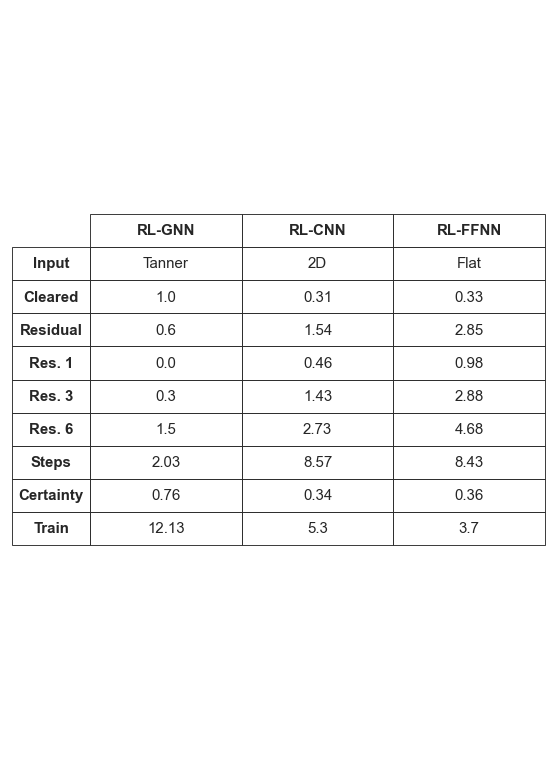

In [241]:
df = pd.DataFrame(data, columns=cols)

df_t = df.set_index("Policy").T

fig, ax = plt.subplots(figsize=(4.8, 6.5))
ax.axis("off")

table = ax.table(
    cellText=df_t.values,
    rowLabels=df_t.index,
    colLabels=df_t.columns,
    cellLoc="center",
    rowLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0.5)
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig("rl_architecture_comparison_vertical.pdf", bbox_inches="tight")
plt.savefig("rl_architecture_comparison_vertical.png", dpi=300, bbox_inches="tight")
plt.show()